In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import category_encoders as ce
import missingno as msno
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.inspection import permutation_importance
from sklearn.model_selection import RandomizedSearchCV
import pickle


df = pd.read_csv("../Data/term-deposit-marketing-2020.csv")


In [3]:
def load_data(df):
    df = pd.read_csv("../Data/term-deposit-marketing-2020.csv")
    return df

In [4]:
df = load_data(df)
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,no


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        40000 non-null  int64 
 1   job        40000 non-null  object
 2   marital    40000 non-null  object
 3   education  40000 non-null  object
 4   default    40000 non-null  object
 5   balance    40000 non-null  int64 
 6   housing    40000 non-null  object
 7   loan       40000 non-null  object
 8   contact    40000 non-null  object
 9   day        40000 non-null  int64 
 10  month      40000 non-null  object
 11  duration   40000 non-null  int64 
 12  campaign   40000 non-null  int64 
 13  y          40000 non-null  object
dtypes: int64(5), object(9)
memory usage: 4.3+ MB


In [6]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'y'],
      dtype='object')

# Feature engineering

# Nominal variables

In [7]:
def nominal_vars(df):
    df['default'] = df['default'].map({'yes': 1, 'no': 0})
    df['housing'] = df['housing'].map({'yes': 1, 'no': 0})
    df['loan'] = df['loan'].map({'yes': 1, 'no': 0})
    df['y'] = df['y'].map({'yes': 1, 'no': 0})
    df["education"] = df["education"].replace("unknown", np.nan)
    df["job"] = df["job"].replace("unknown", np.nan)
    df["contact"] = df["contact"].replace("unknown", np.nan)
    df['job'] = df['job'].map({'management':0,'technician':1,'entrepreneur':2, 'blue-collar':3,
                'retired': 4, 'admin': 5,  'services': 6, 'self-employed': 7,
                'unemployed': 8,  'housemaid': 9, 'student': 10 })
    
    df['marital'] = df['marital'].map({'single':0,'married':1,'divorced':2})
    df['contact'] = df['contact'].map({'cellular': 0, 'telephone': 1})
    return df
   

In [8]:
nominal_vars(df)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,58,0.0,1,tertiary,0,2143,1,0,NaN,5,may,261,1,0
1,44,1.0,0,secondary,0,29,1,0,NaN,5,may,151,1,0
2,33,2.0,1,secondary,0,2,1,1,NaN,5,may,76,1,0
3,47,3.0,1,NaN,0,1506,1,0,NaN,5,may,92,1,0
4,33,NaN,0,NaN,0,1,0,0,NaN,5,may,198,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,53,1.0,1,tertiary,0,395,0,0,0.0,3,jun,107,1,0
39996,30,0.0,0,tertiary,0,3340,0,0,0.0,3,jun,238,3,1
39997,54,5.0,2,secondary,0,200,0,0,0.0,3,jun,170,1,1
39998,34,0.0,1,tertiary,0,1047,0,0,0.0,3,jun,342,1,0


# Dealing with Ordinal data

In [9]:
def ordinal_vars(df):
    education_encoder= ce.OrdinalEncoder(cols=['education'],return_df=True,
                            mapping=[{'col':'education',
    'mapping':{'primary': 0,'secondary': 1,'tertiary': 2}}])
    
    month_encoder= ce.OrdinalEncoder(cols=['month'],return_df=True,
                            mapping=[{'col':'month',
    'mapping':{'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5,
            'jun': 6, 'jul': 7, 'aug': 8, 'oct': 10, 'nov': 11, 'dec': 12}}])
    df[['education']] = education_encoder.fit_transform(df[['education']]).astype('int')
        #[[]] used to indicate dataframe not series
    df[['month']] = month_encoder.fit_transform(df[['month']]).astype('int')
    return df

In [10]:
ordinal_vars(df)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,58,0.0,1,2,0,2143,1,0,NaN,5,5,261,1,0
1,44,1.0,0,1,0,29,1,0,NaN,5,5,151,1,0
2,33,2.0,1,1,0,2,1,1,NaN,5,5,76,1,0
3,47,3.0,1,-1,0,1506,1,0,NaN,5,5,92,1,0
4,33,NaN,0,-1,0,1,0,0,NaN,5,5,198,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,53,1.0,1,2,0,395,0,0,0.0,3,6,107,1,0
39996,30,0.0,0,2,0,3340,0,0,0.0,3,6,238,3,1
39997,54,5.0,2,1,0,200,0,0,0.0,3,6,170,1,1
39998,34,0.0,1,2,0,1047,0,0,0.0,3,6,342,1,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        40000 non-null  int64  
 1   job        39765 non-null  float64
 2   marital    40000 non-null  int64  
 3   education  40000 non-null  int64  
 4   default    40000 non-null  int64  
 5   balance    40000 non-null  int64  
 6   housing    40000 non-null  int64  
 7   loan       40000 non-null  int64  
 8   contact    27235 non-null  float64
 9   day        40000 non-null  int64  
 10  month      40000 non-null  int64  
 11  duration   40000 non-null  int64  
 12  campaign   40000 non-null  int64  
 13  y          40000 non-null  int64  
dtypes: float64(2), int64(12)
memory usage: 4.3 MB


# EDA

# Missing data

In [12]:
def missing_data(df):
    missing = df.isna().sum()/len(df)
    matrix_missing = msno.matrix(df)
    plt.show()
    plt.savefig("../reports/figures/missing_matrix.png")
    return missing, matrix_missing

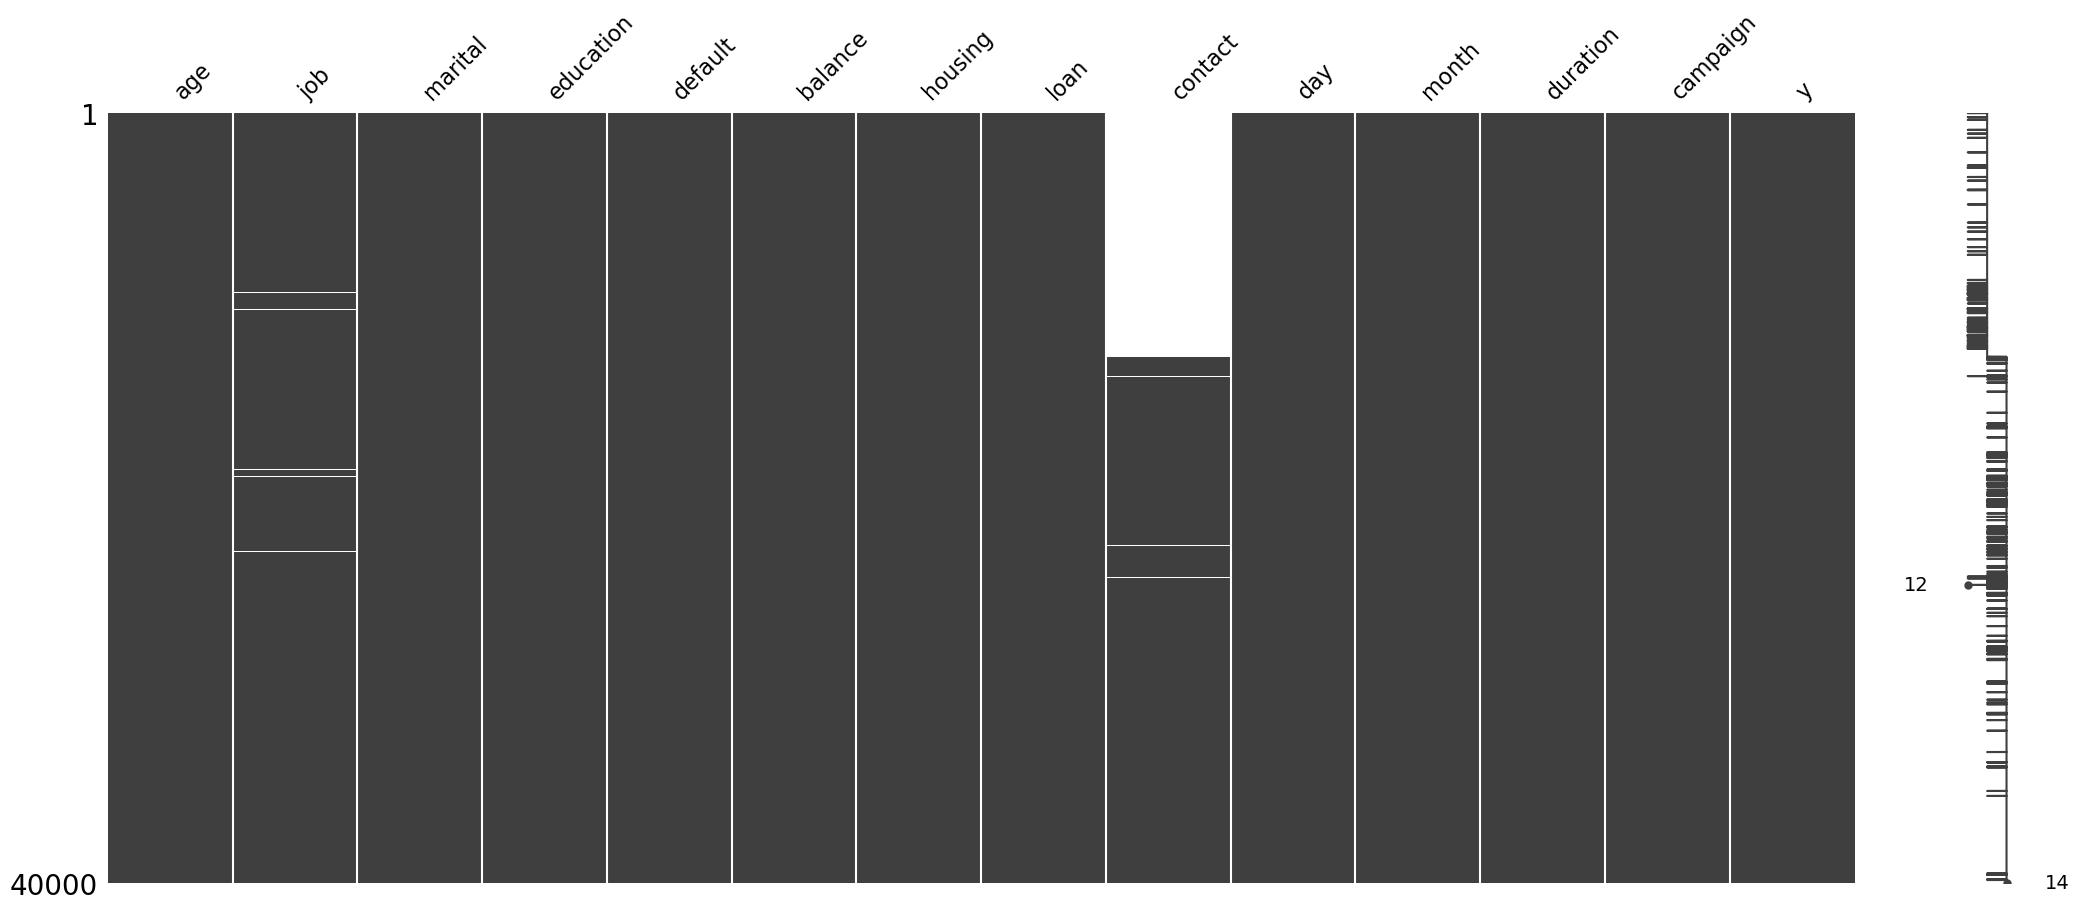

(age          0.000000
 job          0.005875
 marital      0.000000
 education    0.000000
 default      0.000000
 balance      0.000000
 housing      0.000000
 loan         0.000000
 contact      0.319125
 day          0.000000
 month        0.000000
 duration     0.000000
 campaign     0.000000
 y            0.000000
 dtype: float64,
 <Axes: >)

<Figure size 640x480 with 0 Axes>

In [13]:
missing_data(df)

Some missingness exists across three variables, but the reason for the missing values is still unclear. The heatmap does not reveal much, showing only a very weak positive correlation in missingness between job and education (0.2) and between contact and education (0.1)

Using mode imputation for the contact variable may introduce bias because approximately 32% of its values are missing. Replacing such a large proportion with the most frequent category could significantly distort the original distribution. In contrast, the missingness in education (around 4%) and job (around 0.06%) is very small, so mode imputation for these two variables is less likely to affect the model.

# Outlier analysis 

he distributions help determine which outlier detection method is most appropriate. The Z-score method may not be suitable, as more than three numeric variables are strongly right-skewed, while Z-score-based outlier detection works best with approximately normally distributed data. Therefore, the quantile/IQR method is preferred because it is more robust to skewed distributions and extreme values. The differences in the ranges and distributions of the numeric variables may also indicate the need for feature scaling later, depending on the machine-learning model used.

In [14]:
def histgrams(df):
    age = sns.histplot(df['age'])
    plt.savefig("../reports/figures/histogram_age.png")
    plt.show()
    balance = sns.histplot(df['balance'])
    plt.savefig("../reports/figures/histogram_balance.png")
    plt.show()
    duration = sns.histplot(df['duration'])
    plt.savefig("../reports/figures/histogram_duration.png")
    plt.show()
    day = sns.histplot(df['day'])
    plt.savefig("../reports/figures/histogram_day.png")
    plt.show()
    return age, balance, duration, day

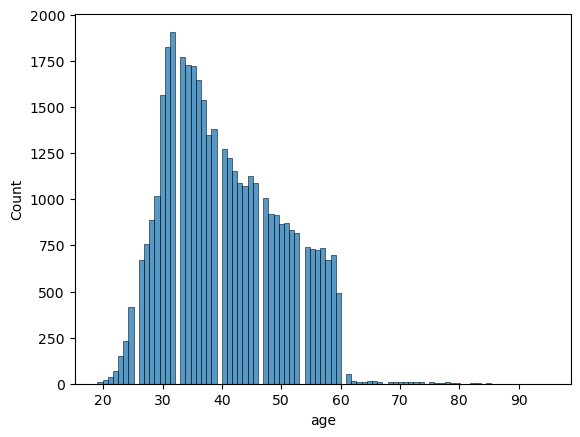

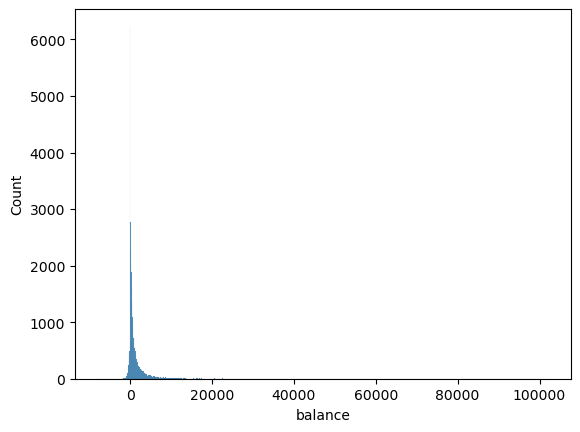

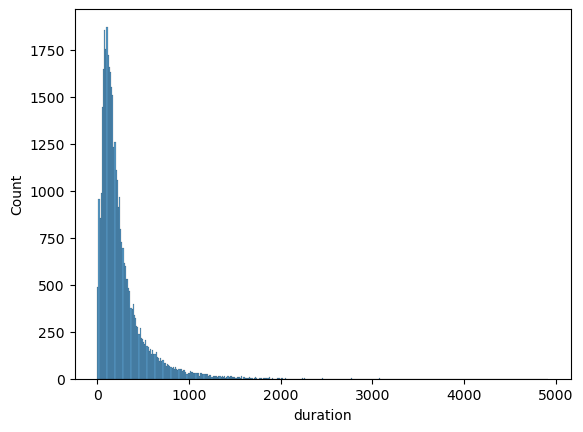

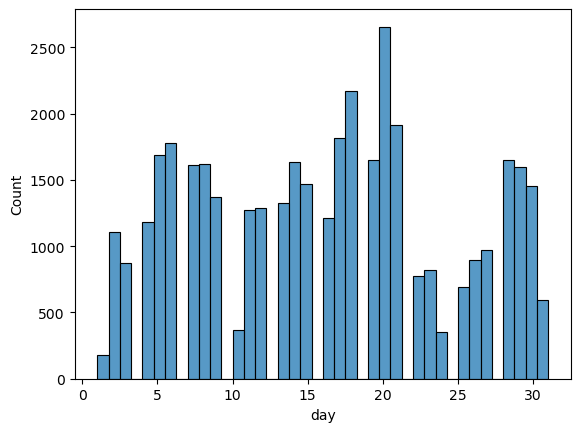

(<Axes: xlabel='age', ylabel='Count'>,
 <Axes: xlabel='balance', ylabel='Count'>,
 <Axes: xlabel='duration', ylabel='Count'>,
 <Axes: xlabel='day', ylabel='Count'>)

In [15]:
histgrams(df)

In [16]:
def outlier_analysis(df, column):
    q1_q = df[column].quantile(0.25)
    q3_q = df[column].quantile(0.75)
    # Find the IQR
    IQR = q3_q - q1_q
    factor = 2.5 # 2.5 × IQR means you only mark really extreme points as outliers
    lower_limit_q = q1_q - IQR*factor
    upper_limit_q = q3_q + IQR*factor

    is_lower_q = df[column] < lower_limit_q

    is_higher_q = df[column] > upper_limit_q
    # Combine the masks to filter for outliers
    outliers = df[column][is_lower_q | is_higher_q] 
    # Count and print the number of outliers
    print(len(outliers))
    return outliers

In [17]:
age_outliers = outlier_analysis(df,"age")
duration_outliers = outlier_analysis(df,"duration")
day_outiers = outlier_analysis(df,"day") 
balance_outliers = outlier_analysis(df,"balance")

4
1514
0
2761


In [18]:
def correlation_matrix(df):
    corr = df.select_dtypes(include='number').corr()
    plt.figure(figsize=(9, 7))
    mask = np.triu(np.ones_like(corr))
    correlation_matrix = sns.heatmap(corr, center=0,
            mask=mask,
              linewidths=1,
              annot=True,
                fmt=".2f"
)
    plt.title("Correlation matrix")
    plt.savefig("../reports/figures/correlation_matrix.png")
    plt.show()
    return correlation_matrix

No strong correlations were observed between the numeric variables. The highest correlation was 46% between the duration of the last contact (in seconds) and whether the client subscribed to a term deposit, followed by a 39% correlation between marital status and age.

In [ ]:
correlation_matrix(df)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        40000 non-null  int64  
 1   job        39765 non-null  float64
 2   marital    40000 non-null  int64  
 3   education  40000 non-null  int64  
 4   default    40000 non-null  int64  
 5   balance    40000 non-null  int64  
 6   housing    40000 non-null  int64  
 7   loan       40000 non-null  int64  
 8   contact    27235 non-null  float64
 9   day        40000 non-null  int64  
 10  month      40000 non-null  int64  
 11  duration   40000 non-null  int64  
 12  campaign   40000 non-null  int64  
 13  y          40000 non-null  int64  
dtypes: float64(2), int64(12)
memory usage: 4.3 MB


In [ ]:
def split_data():
    y = df['y']
    X = df.drop('y',axis=1)
    X_train, X_test, y_train, y_test = train_test_split(X, y,
        test_size=0.2, random_state=42, stratify= y )
    return X_train, X_test, y_train, y_test

In [ ]:
X_train, X_test, y_train, y_test = split_data()

In [ ]:
def transformers(X_train, X_test):
    numeric_vars = ['balance', 'age', 'duration']
    missing_vars = ['job','education','contact']

    scaler = StandardScaler()
    mode_imputer = SimpleImputer(strategy="most_frequent")


    X_train[numeric_vars] = scaler.fit_transform(X_train[numeric_vars])
    X_test[numeric_vars] = scaler.fit_transform(X_test[numeric_vars])

    X_train[missing_vars] = mode_imputer.fit_transform(X_train[missing_vars])
    X_test[missing_vars] = mode_imputer.transform(X_test[missing_vars])
    return X_train, X_test

In [ ]:
transformers(X_train, X_test)

(            age  job  marital  education  default   balance  housing  loan  \
 35752 -0.053962  0.0        1        2.0        0 -0.440161        1     0   
 10898  0.361478  3.0        1        1.0        0  0.139638        1     0   
 27424 -0.677122  8.0        1        1.0        0  1.784360        1     0   
 17179 -0.780982  0.0        1        2.0        0 -0.319571        1     1   
 7744  -0.884842  6.0        1        1.0        0 -0.451909        1     0   
 ...         ...  ...      ...        ...      ...       ...      ...   ...   
 26813 -0.469402  0.0        2        2.0        0 -0.440161        1     0   
 38199 -0.677122  0.0        0        2.0        0  3.481602        1     0   
 15588 -0.988702  1.0        1        1.0        0  0.233968        1     0   
 13902  1.296219  4.0        1        0.0        0 -0.419084        0     1   
 7144   0.257618  0.0        1       -1.0        0  1.346919        1     0   
 
        contact  day  month  duration  campaign  


In [ ]:
def under_sampling(X_train, y_train):
    rus = RandomUnderSampler(random_state=42)
    X_train, y_train = rus.fit_resample(X_train, y_train)
    return X_train, y_train


In [ ]:
X_train, y_train = under_sampling(X_train, y_train)

In [ ]:
def over_sampling(X_train, y_train):
    ros = RandomOverSampler(random_state=42)
    X_train, y_train = ros.fit_resample(X_train, y_train)
    return X_train, y_train

In [ ]:
X_train, y_train = over_sampling(X_train, y_train)

In [ ]:
def train_model(model, X_train, y_train):
    model.fit(X_train, y_train)
    return model

In [ ]:
def make_predictions(model, X_test):
    predictions = model.predict(X_test)
    return predictions

In [ ]:
def classification_bymodel(predictions):
    labels = ["Not subscribed", "subscribed"]
    
    classification_report_model = classification_report(
    y_test,
    predictions,
    target_names=labels)
    
    return classification_report_model

In [ ]:
# KNN modeling
knn = KNeighborsClassifier(n_neighbors=20)
trained_knn = train_model(knn, X_train, y_train)
with open("../models/knn.pkl", "wb") as file:
    pickle.dump(trained_knn, file)
knn_predictions = make_predictions(trained_knn, X_test)
knn_report = classification_bymodel(knn_predictions)
print(knn_report)

                precision    recall  f1-score   support

Not subscribed       0.98      0.84      0.90      7421
    subscribed       0.27      0.78      0.41       579

      accuracy                           0.83      8000
     macro avg       0.63      0.81      0.65      8000
  weighted avg       0.93      0.83      0.87      8000



In [ ]:
# Logistic Regression modeling
logreg = LogisticRegression(random_state =42)
trained_logreg = train_model(logreg, X_train, y_train)
with open("../models/lr.pkl","wb") as file:
    pickle.dump(trained_logreg, file)
logreg_predictions = make_predictions(trained_logreg, X_test)
logreg_report = classification_bymodel(logreg_predictions)
print(logreg_report)

                precision    recall  f1-score   support

Not subscribed       0.98      0.85      0.91      7421
    subscribed       0.29      0.79      0.42       579

      accuracy                           0.84      8000
     macro avg       0.63      0.82      0.66      8000
  weighted avg       0.93      0.84      0.87      8000



In [ ]:
# SVM modeling
svm = SVC(random_state =42)
trained_svm = train_model(svm, X_train, y_train)
with open("../models/svm.pkl", "wb") as file:
    pickle.dump(trained_svm,file)
svm_predictions = make_predictions(trained_svm, X_test)
svm_report = classification_bymodel(svm_predictions)
print(svm_report)

                precision    recall  f1-score   support

Not subscribed       0.99      0.84      0.91      7421
    subscribed       0.30      0.85      0.44       579

      accuracy                           0.84      8000
     macro avg       0.64      0.85      0.68      8000
  weighted avg       0.94      0.84      0.88      8000



In [ ]:
# Decision tree modeling
normal_tree = DecisionTreeClassifier(random_state=42,
                                     class_weight='balanced')
trained_normal_tree = train_model(normal_tree, X_train, y_train)
with open("../models/normal_tree.pkl", "wb") as file:
    pickle.dump(trained_normal_tree,file)
tree_predictions = make_predictions(trained_normal_tree,X_test)
tree_report = classification_bymodel(tree_predictions)
print(tree_report)

                precision    recall  f1-score   support

Not subscribed       0.95      0.96      0.96      7421
    subscribed       0.41      0.34      0.37       579

      accuracy                           0.92      8000
     macro avg       0.68      0.65      0.67      8000
  weighted avg       0.91      0.92      0.91      8000



In [ ]:
# Xgboost modeling
xgboost = XGBClassifier(random_state =42)
trained_xgboost = train_model(xgboost,X_train,y_train)
with open("../models/xgboost.pkl", "wb") as file:
    pickle.dump(trained_xgboost,file)
xgboost_predications = make_predictions(trained_xgboost,X_test)
xgboost_report = classification_bymodel(xgboost_predications)
print(xgboost_report)

                precision    recall  f1-score   support

Not subscribed       0.98      0.92      0.95      7421
    subscribed       0.43      0.75      0.55       579

      accuracy                           0.91      8000
     macro avg       0.71      0.84      0.75      8000
  weighted avg       0.94      0.91      0.92      8000



In [ ]:
# Random Forest modeling
rf = RandomForestClassifier(random_state=42,  
                            class_weight='balanced')
trained_rf = train_model(rf,X_train,y_train)
with open("../models/rf.pkl", "wb") as file:
    pickle.dump(trained_rf,file)
rf_predictions = make_predictions(trained_rf, X_test)
rf_report = classification_bymodel(rf_predictions)
print(rf_report)

                precision    recall  f1-score   support

Not subscribed       0.96      0.97      0.96      7421
    subscribed       0.56      0.42      0.48       579

      accuracy                           0.93      8000
     macro avg       0.76      0.70      0.72      8000
  weighted avg       0.93      0.93      0.93      8000



# Random Search

In [ ]:
parameter_grid = {
    'max_depth': list(range(2, 30)),
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5],
    'scale_pos_weight': [1, 2, 5, 10, 20, 30, 39]
}


number_models = 10
Xgboost_class = RandomizedSearchCV(
    estimator=xgboost,
    param_distributions=parameter_grid,
    n_iter=number_models,
    scoring='accuracy',
    n_jobs=-1,
    cv=5,
)
Xgboost_class.fit(X_train, y_train)
Xgboost_class.best_params_

{'scale_pos_weight': 2, 'max_depth': 28, 'learning_rate': 0.5}

In [ ]:
parameter_grid = {
    "max_depth": [20, 25, 30, 35],
    "learning_rate": [0.4, 0.5, 0.6, 0.7],
    "scale_pos_weight": [25, 30, 35, 39] }


number_models = 10
Xgboost_class = RandomizedSearchCV(
    estimator=xgboost,
    param_distributions=parameter_grid,
    n_iter=number_models,
    scoring='f1',
    n_jobs=-1,
    cv=5,
)
Xgboost_class.fit(X_train, y_train)
Xgboost_class.best_params_

{'scale_pos_weight': 25, 'max_depth': 35, 'learning_rate': 0.6}

In [ ]:
xgboost_tuned = XGBClassifier(random_state =42,
                         scale_pos_weight = 25,
                           max_depth = 35, 
                           learning_rate = 0.6)
trained_xgboost_tuned = train_model(xgboost_tuned,X_train,y_train)
with open("../models/tuned_xgboost.pkl", "wb") as file:
    pickle.dump(trained_xgboost_tuned,file)
xgboost_predications = make_predictions(trained_xgboost_tuned,X_test)
xgboost_report = classification_bymodel(xgboost_predications)
print(xgboost_report)

                precision    recall  f1-score   support

Not subscribed       0.97      0.95      0.96      7421
    subscribed       0.49      0.61      0.54       579

      accuracy                           0.93      8000
     macro avg       0.73      0.78      0.75      8000
  weighted avg       0.93      0.93      0.93      8000



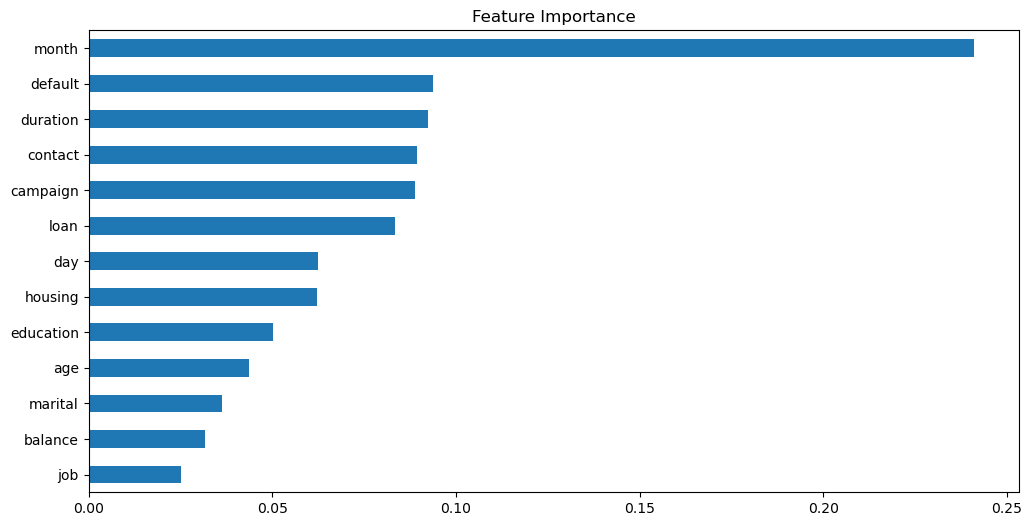

In [ ]:
def feature_importance(model, X_train):
    importances = pd.Series(model.feature_importances_, index=X_train.columns)
    # A series is a better representation than using a dictionary 
    # index is needed for the labels
    top_features = importances.sort_values(ascending=False)
    # sort first for the importance, then sort again for the visual order of the va
    top_features.sort_values().plot(kind='barh', figsize=(12,6))
    # A horizontal bar chart is much better than a vertical bar chart to represent 
    plt.title("Feature Importance")
    plt.savefig("../reports/figures/feature_importance.png")
    plt.show()


feature_importance(trained_xgboost_tuned, X_train)


In [ ]:
importance = pd.Series(permutation_importance(
trained_xgboost_tuned, X_test, y_test, n_repeats=50, random_state = 42
).importances_mean, index=X_train.columns)
# shuffling each feature 50 times to provide a better result of stability 
print(importance.sort_values(ascending=False))

NameError: name 'pd' is not defined

duration was the most important feature according to permutation importance on the unseen test data. Randomly shuffling duration reduced model accuracy by approximately 5.4 percentage points on average, indicating that the model relies substantially on this variable for prediction then month by approximately 3.2 percentage then day by approximately 2.3